# ARoF ARVTDNN-DPD - Hyperparameters optimization with Optuna

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent.parent)

sys.path.append(project_path)

In [2]:
import optuna
import numpy as np
import torch as th
import matplotlib.pyplot as plt

from functools                import partial
from scipy.signal             import firwin
from tqdm.notebook            import tqdm

from optic.comm.ofdm          import modulateOFDM
from optic.comm.modulation    import modulateGray
from optic.dsp.core           import pnorm, clockSamplingInterp, finddelay
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters

from dpd.channel_models       import RoF_channel
from dpd.optuna_tasks         import objective_rof_dpd, get_pareto, get_best_pareto

from optuna.trial             import TrialState
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - OFDM signal generation

In [4]:
# Parâmetros de modulação
modOrder  = 64                 # Modulation order
constType = 'qam'              # Constellation format
Rb = 5e9                       # Bitrate
SpS = 32

# OFDM parameters
paramOFDM = parameters()
paramOFDM.G   = 32              
paramOFDM.SpS = SpS

paramOFDM.Nfft = 2**10
paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft - 1, 32, dtype = np.int64)

Nz = len(paramOFDM.nullCarriers)
Np = len(paramOFDM.pilotCarriers)
Ni = paramOFDM.Nfft - Nz - Np
numOFDMframes = 100

In [5]:
# Bits generation
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

# Symbols modulation
symbTx = modulateGray(bits, modOrder, constType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [6]:
# OFDM signal generation
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

Rs = Rb / ( Ni / (paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder))
Fs = Rs * paramOFDM.SpS

SpS_DPD = 4
Fs_DPD = Rs * SpS_DPD

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = paramOFDM.SpS * paramOFDM.G * (1/Fs)
t_symb = paramOFDM.SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

### 2 - A-RoF channel

In [7]:
# MZM parameters
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.P_laser = 0
paramMZM.Pin_MZM = 17

# RF parameters
paramRF = parameters()
paramRF.fc_e = 3.55e9
paramRF.bw = Rs
paramRF.Fs = Fs

# Optical fiber parameters
paramFiber = parameters()
paramFiber.L = 20
paramFiber.alpha = 0.2
paramFiber.D = 16
paramFiber.Fc = 193.1e12
paramFiber.Fs = Fs

# Photodiode parameters
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

# PA parameters
paramPA = parameters()
paramPA.model_name = "modified_rapp"
paramPA.g = 16
paramPA.x_sat = 1.9
paramPA.sigma_p = 1.1
paramPA.alpha = -345
paramPA.beta = 0.17
paramPA.q = 4

In [8]:
paramRoF = parameters()
paramRoF.paramMZM = paramMZM
paramRoF.paramRF = paramRF
paramRoF.paramFiber = paramFiber
paramRoF.paramPD = paramPD
paramRoF.paramPA = paramPA

sigRx_PA = RoF_channel(sigTx, paramRoF, filter_numtaps = 4096)

hlp = firwin(4096, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx_PA)

### 3 - Data for training

In [9]:
hlp = firwin(4096, SpS_DPD*Rs/2, fs = Fs)

sigRef = clockSamplingInterp(pnorm(firFilter(hlp, sigTx).reshape(-1, 1)), Fs, Fs_DPD).ravel()
sigIn  = clockSamplingInterp(pnorm(firFilter(hlp, sigRx_PA).reshape(-1, 1)), Fs, Fs_DPD).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

### 4 - Optuna hyperparameter optimization

In [14]:
paramModel = parameters()
paramModel.model_name = "ARVTDNN"
paramModel.K = 2
paramModel.M = 0
paramModel.hidden_layers = [16, 8]
paramModel.activation = "relu"

paramTrain = parameters()
paramTrain.trainTestFrac = 0.75
paramTrain.batchSize     = 1_000
paramTrain.shuffle       = False
paramTrain.adaptLearningRatio = True
paramTrain.lr      = 5e-3
paramTrain.epochs  = 500
paramTrain.pgrsBar = False
paramTrain.device  = "cuda" # "cpu"

data = parameters()
data.sigIn     = th.from_numpy(sigIn[0:20_000]).to(paramTrain.device).type(th.complex64)
data.sigRef    = th.from_numpy(sigRef[0:20_000]).to(paramTrain.device).type(th.complex64)
data.sigTx     = sigTx 
data.Rs        = Rs
data.SpS       = SpS
data.Fs        = Fs
data.Fs_DPD    = Fs_DPD
data.modOrder  = modOrder
data.constType = constType

paramMetrics = parameters()
paramMetrics.bw_for_aclr = Rs/2
paramMetrics.offset_for_aclr = 10e6
paramMetrics.discard = 100
paramMetrics.metrics = ["EVM", "ACLR", "NFLOP"]

In [17]:
study_num = 1
n_trials  = 500
timeout   = 60*60*20

metrics = ["ACLR", "EVM", "NFLOPs"]
sampler = "TPESampler"

paramMetrics.model_path = file_path + f"\\study{study_num}\\models"

In [18]:
objective_ILA = partial(objective_rof_dpd, data = data, paramOFDM = paramOFDM, paramRoF = paramRoF, 
                        paramModel = paramModel, paramTrain = paramTrain, paramMetrics = paramMetrics)

if sampler == "GridSampler":
    study_ILA = optuna.create_study(directions=["minimize", "minimize", "minimize"], sampler = optuna.samplers.GridSampler(search_space))

elif sampler == "TPESampler":
    study_ILA = optuna.create_study(directions=["minimize", "minimize", "minimize"], sampler = optuna.samplers.TPESampler())

else:
    print("No sampler")
    
study_ILA.optimize(objective_ILA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)

  0%|          | 0/500 [00:00<?, ?it/s]

In [19]:
description = f"""
sampler: {sampler}
ntrials: {n_trials} 

Hyperparameters range: 
N1: 5 - 30
N2: 5 - 20
M: 1 - 5
K: 1 - 3

Obs.: EVM, ACLR and NFLOP as objective functions
"""
with open(file_path + f"\\study{study_num}\\description.txt", "w") as description_file:
    description_file.write(description)

In [20]:
complete_trials   = study_ILA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
n_complete_trials = len(complete_trials)

study_N1 = np.zeros(n_complete_trials)
study_N2 = np.zeros(n_complete_trials)
study_K  = np.zeros(n_complete_trials)
study_M  = np.zeros(n_complete_trials)

study_EVM   = np.zeros(n_complete_trials)
study_ACLR  = np.zeros(n_complete_trials)
study_NFLOP = np.zeros(n_complete_trials)

for j in range(n_complete_trials):
    trials_params  = complete_trials[j].params
    study_EVM[j]   = complete_trials[j].values[0]
    study_ACLR[j]  = complete_trials[j].values[1]
    study_NFLOP[j] = complete_trials[j].values[2]

    study_N1[j] = trials_params["N1"]
    study_N2[j] = trials_params["N2"]
    study_K[j]  = trials_params["K"]
    study_M[j]  = trials_params["M"]

np.savetxt(file_path + f'\\study{study_num}\\parameters\\N1.txt', study_N1, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\parameters\\N2.txt', study_N2, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\parameters\\K.txt', study_K, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\parameters\\M.txt', study_M, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\results\\NFLOp.txt', study_NFLOP, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\results\\ACLR.txt', study_ACLR, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\results\\EVM.txt', study_EVM, fmt = '%f')

## EVM vs NFLOP

In [21]:
# EVM vs NFLOPs
pareto_evm, pareto_trials_evm = get_pareto(study_EVM, study_NFLOP, n_trials)
best_evm, best_arg_evm, ideal_evm = get_best_pareto(pareto_evm, weights = (2, 1))

print(f"Best solution: \nTrial = {pareto_trials_evm[best_arg_evm]}, NFLOP = {best_evm[0]:.0f}, EVM = {best_evm[1]:.3f} %\n")

print("-Pareto solutions:")
for i, tt in enumerate(pareto_trials_evm):
    print(f"Trial {tt} \nNFLOP = {study_NFLOP[tt-1]:.1f} \nEVM = {study_EVM[tt-1]:.3f} % \nACLR = {study_ACLR[tt-1]:.3f} dB, \nN1 = {study_N1[tt-1]}, \nN2 = {study_N2[tt-1]}, \nK = {study_K[tt-1]}, \nM = {study_M[tt-1]}\n")

Best solution: 
Trial = 318, NFLOP = 309, EVM = 4.668 %

-Pareto solutions:
Trial 248 
NFLOP = 1368.0 
EVM = 4.244 % 
ACLR = -28.377 dB, 
N1 = 22.0, 
N2 = 18.0, 
K = 3.0, 
M = 1.0

Trial 420 
NFLOP = 951.0 
EVM = 4.303 % 
ACLR = -28.071 dB, 
N1 = 21.0, 
N2 = 14.0, 
K = 1.0, 
M = 1.0

Trial 49 
NFLOP = 894.0 
EVM = 4.532 % 
ACLR = -28.097 dB, 
N1 = 22.0, 
N2 = 12.0, 
K = 1.0, 
M = 1.0

Trial 76 
NFLOP = 775.0 
EVM = 4.537 % 
ACLR = -28.045 dB, 
N1 = 20.0, 
N2 = 11.0, 
K = 1.0, 
M = 1.0

Trial 437 
NFLOP = 528.0 
EVM = 4.544 % 
ACLR = -28.047 dB, 
N1 = 21.0, 
N2 = 5.0, 
K = 1.0, 
M = 1.0

Trial 146 
NFLOP = 528.0 
EVM = 4.599 % 
ACLR = -27.973 dB, 
N1 = 21.0, 
N2 = 5.0, 
K = 1.0, 
M = 1.0

Trial 178 
NFLOP = 324.0 
EVM = 4.630 % 
ACLR = -28.148 dB, 
N1 = 5.0, 
N2 = 13.0, 
K = 3.0, 
M = 1.0

Trial 318 
NFLOP = 309.0 
EVM = 4.668 % 
ACLR = -28.100 dB, 
N1 = 5.0, 
N2 = 12.0, 
K = 3.0, 
M = 1.0

Trial 467 
NFLOP = 309.0 
EVM = 4.980 % 
ACLR = -27.857 dB, 
N1 = 5.0, 
N2 = 12.0, 
K = 3.0, 
M =

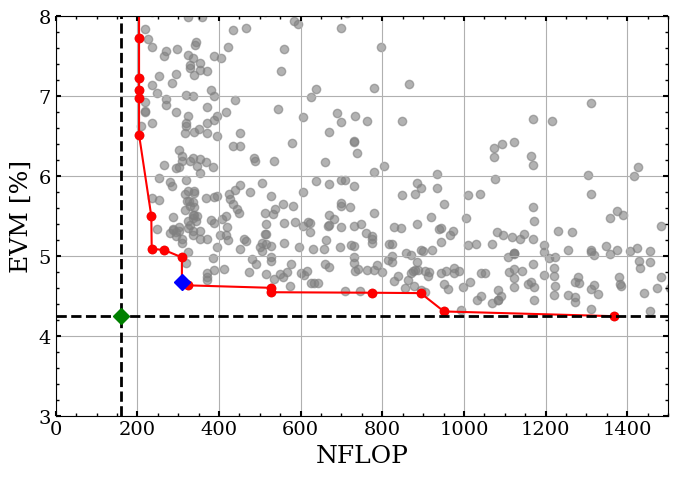

In [30]:
fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(study_NFLOP, study_EVM, color = "gray", alpha = 0.6)
axs.plot(pareto_evm[:,1], pareto_evm[:,0], "-o", color = "r")

axs.axvline(ideal_evm[0], ls = "--", lw = 2, color = "k")
axs.axhline(ideal_evm[1], ls = "--", lw = 2, color = "k")
axs.plot(ideal_evm[0], ideal_evm[1], "D", ms = 8, color = "g", zorder = 6)

axs.plot(pareto_evm[best_arg_evm, 1], pareto_evm[best_arg_evm, 0], "D", ms = 8, color = "b", zorder = 6)

axs.set_xlim(0, 1.5e3)
axs.set_ylim(3., 8)
axs.set_xlabel("NFLOP", fontsize = 18)
axs.set_ylabel("EVM [%]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()

## ACLR vs NFLOP

In [23]:
# ACRL vs NFLOPs
pareto_aclr, pareto_trials_aclr = get_pareto(study_ACLR, study_NFLOP, n_trials)
best_aclr, best_arg_aclr, ideal_aclr = get_best_pareto(pareto_aclr, weights = (2, 1))

print(f"Best solution: \nTrial = {pareto_trials_aclr[best_arg_aclr]}, NFLOP = {best_aclr[0]:.0f}, ACLR = {best_aclr[1]:.3f} dB\n")

print("-Pareto solutions:")
for i, tt in enumerate(pareto_trials_aclr):
    print(f"Trial {tt} \nNFLOP = {study_NFLOP[tt-1]:.1f} \nEVM = {study_EVM[tt-1]:.3f} % \nACLR = {study_ACLR[tt-1]:.3f} dB, \nN1 = {study_N1[tt-1]}, \nN2 = {study_N2[tt-1]}, \nK = {study_K[tt-1]}, \nM = {study_M[tt-1]}\n")

Best solution: 
Trial = 272, NFLOP = 235, ACLR = -27.738 dB

-Pareto solutions:
Trial 183 
NFLOP = 1311.0 
EVM = 4.579 % 
ACLR = -28.512 dB, 
N1 = 26.0, 
N2 = 13.0, 
K = 3.0, 
M = 1.0

Trial 361 
NFLOP = 1221.0 
EVM = 4.511 % 
ACLR = -28.440 dB, 
N1 = 22.0, 
N2 = 15.0, 
K = 3.0, 
M = 1.0

Trial 299 
NFLOP = 1172.0 
EVM = 4.442 % 
ACLR = -28.378 dB, 
N1 = 22.0, 
N2 = 14.0, 
K = 3.0, 
M = 1.0

Trial 66 
NFLOP = 1068.0 
EVM = 4.405 % 
ACLR = -28.369 dB, 
N1 = 23.0, 
N2 = 11.0, 
K = 3.0, 
M = 1.0

Trial 265 
NFLOP = 878.0 
EVM = 4.617 % 
ACLR = -28.239 dB, 
N1 = 16.0, 
N2 = 14.0, 
K = 3.0, 
M = 1.0

Trial 178 
NFLOP = 324.0 
EVM = 4.630 % 
ACLR = -28.148 dB, 
N1 = 5.0, 
N2 = 13.0, 
K = 3.0, 
M = 1.0

Trial 318 
NFLOP = 309.0 
EVM = 4.668 % 
ACLR = -28.100 dB, 
N1 = 5.0, 
N2 = 12.0, 
K = 3.0, 
M = 1.0

Trial 371 
NFLOP = 294.0 
EVM = 7.270 % 
ACLR = -27.865 dB, 
N1 = 5.0, 
N2 = 11.0, 
K = 3.0, 
M = 1.0

Trial 272 
NFLOP = 235.0 
EVM = 5.088 % 
ACLR = -27.738 dB, 
N1 = 6.0, 
N2 = 5.0, 
K = 3

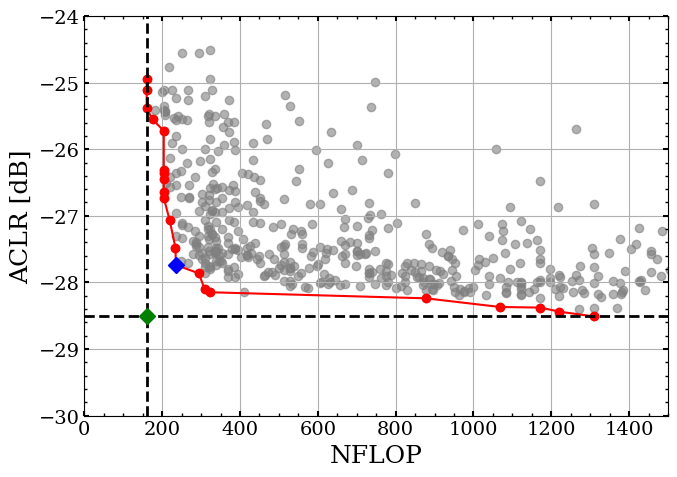

In [28]:
fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(study_NFLOP, study_ACLR, color = "gray", alpha = 0.6)
axs.plot(pareto_aclr[:,1], pareto_aclr[:,0], "-o", color = "r")

axs.axvline(ideal_aclr[0], ls = "--", lw = 2, color = "k")
axs.axhline(ideal_aclr[1], ls = "--", lw = 2, color = "k")
axs.plot(ideal_aclr[0], ideal_aclr[1], "D", ms = 8, color = "g", zorder = 6)

axs.plot(pareto_aclr[best_arg_aclr, 1], pareto_aclr[best_arg_aclr, 0], "D", ms = 8, color = "b", zorder = 6)

axs.set_xlim(0, 1.5e3)
axs.set_ylim(-30, -24)
axs.set_xlabel("NFLOP", fontsize = 18)
axs.set_ylabel("ACLR [dB]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()